# Projectile Motion with Quadratic Air Resistance

## From verification problem to modeling problem

In the no-drag notebook, the exact trajectory allowed us to verify three numerical update rules. We now add a force that depends on the projectile's velocity. The goals are to see how a more realistic model changes the equations and to recognize that numerical error and model effects must still be kept conceptually separate.

We will compare Euler, Euler–Cromer, and the average-velocity position update using the **same** initial conditions, timestep, drag law, and stopping rule. A no-drag analytical curve remains on the plots as a physical reference, not as an exact solution of the drag model.

In [8]:
from array import array
import numpy as np
import math

## Building the differential-equation model

The two-dimensional state is

$$\mathbf{s}(t)=(x,y,v_x,v_y),$$

with kinematic equations

$$\frac{dx}{dt}=v_x, \qquad \frac{dy}{dt}=v_y.$$

For quadratic drag, the force vector is opposite the velocity vector and has magnitude

$$F_D=\frac{1}{2}C_D\rho A v^2,$$

where $v=\sqrt{v_x^2+v_y^2}$. Therefore

$$\mathbf{F}_D=-\frac{1}{2}C_D\rho A\,v\mathbf{v}.$$

Dividing by the mass and defining

$$k=-\frac{C_D\rho A}{2m},$$

gives the coupled acceleration equations

$$a_x=kvv_x,$$

$$a_y=kvv_y-g.$$

The minus sign is contained in $k$, so the drag contribution always opposes the corresponding velocity component. The equations are **coupled** because both accelerations depend on the total speed $v$, which contains both velocity components.

In [9]:
# Initial Conditions
speed = 55.8
theta = 45.0
y1 = 0.0


# Other constants - golf ball - D = 0.0427m, m = 0.04593kg
Cd = 0.20 # drag coefficient
area = 0.001432 # cross sectional area of projectile
grav = 9.81 # gravitional acceleration
mass = 0.04593 # mass in kg
rho = 1.225 # density of air (kg/m^3)
air_const = -0.5*Cd*rho*area/mass
Pi = math.pi

## Initial conditions and physical parameters

The parameters below approximate a golf ball. They define the model; they are not outputs of the numerical method. In SI units, $k$ has dimensions of inverse length, so $kvv_x$ has dimensions of acceleration.

The launch angle is converted into initial velocity components exactly as in the no-drag problem. Keeping the physical parameters in one cell makes it easy to ask modeling questions later: What changes if the mass, area, drag coefficient, or air density is varied?

In [10]:
r1 = array('d')
v1 = array('d')
r = array('d')
v = array('d')
accel = array('d')

r1.append(0)
r1.append(y1)
v1.append(speed*math.cos(theta*Pi/180.0))
v1.append(speed*math.sin(theta*Pi/180.0))

r.append(r1[0])
r.append(r1[1])
v.append(v1[0])
v.append(v1[1])
accel.append(0)
accel.append(0)

## Creating independent numerical states

Each method needs its own mutable position and velocity arrays. If two methods shared the same arrays, the first update would change the starting point seen by the second and the comparison would be invalid.

The arrays `r`, `re`, and `rec` will hold the states for the average-velocity, Euler, and Euler–Cromer calculations, respectively. Every state begins with the same $\mathbf{r}_0$ and $\mathbf{v}_0$.

In [11]:
# Setup arrays for Euler and Euler-Cromer Methods
re = array('d')
ve = array('d')
accele = array('d')

re.append(r1[0])
re.append(r1[1])
ve.append(v1[0])
ve.append(v1[1])
accele.append(0)
accele.append(0)

rec = array('d')
vec = array('d')
accelec = array('d')

rec.append(r1[0])
rec.append(r1[1])
vec.append(v1[0])
vec.append(v1[1])
accelec.append(0)
accelec.append(0)


In [12]:
tau = 0.02 # timestep in seconds
maxStep = 1000000 # maximum number of steps

xplot = array('d')
yplot = array('d')
xplote = array('d')
yplote = array('d')
xplotec = array('d')
yplotec = array('d')
xNoAir = array('d')
yNoAir = array('d')
time = array('d')
timee = array('d')
timeec = array('d')
timeNoAir = array('d')

## Timestep and recorded quantities

All methods use $\tau=0.02\ \mathrm{s}$. A shared timestep is essential for a controlled comparison. `maxStep` is a safety limit: under normal conditions the loop ends when the projectile crosses the ground, long before one million iterations.

For each method we record $x(t)$ and $y(t)$. We also evaluate the exact no-drag equations at the same times. The no-drag arrays are deliberately only a reference over the simulated time interval; the drag and no-drag projectiles do not land simultaneously.

## The three updates inside the loop

At the beginning of every step, each method computes its own speed and acceleration from its own current velocity.

**Euler** advances position and velocity using beginning-of-step values:

$$\mathbf{r}_{n+1}=\mathbf{r}_n+\tau\mathbf{v}_n,$$

$$\mathbf{v}_{n+1}=\mathbf{v}_n+\tau\mathbf{a}(\mathbf{v}_n).$$

**Euler–Cromer** updates velocity first and then uses that endpoint velocity for position:

$$\mathbf{v}_{n+1}=\mathbf{v}_n+\tau\mathbf{a}(\mathbf{v}_n),$$

$$\mathbf{r}_{n+1}=\mathbf{r}_n+\tau\mathbf{v}_{n+1}.$$

The code labeled **MidPoint Method** predicts the endpoint velocity from the beginning-of-step acceleration and uses the average velocity for position:

$$\mathbf{v}_{n+1}=\mathbf{v}_n+\tau\mathbf{a}(\mathbf{v}_n),$$

$$\mathbf{r}_{n+1}=\mathbf{r}_n+\tau
\frac{\mathbf{v}_n+\mathbf{v}_{n+1}}{2}.$$

This position update was exact for constant acceleration. With drag, however, acceleration changes throughout the step. Because acceleration is not reevaluated at an estimated midpoint, this is not a full second-order midpoint integrator for the coupled state; the velocity update remains forward Euler. The label is retained to connect with the preceding notebook, but the limitation matters when interpreting accuracy.

In [13]:
endtime = 0
nelements = 0
for iStep in range(1,maxStep+1):
    
    t = (iStep-1)*tau
        
    xplot.append(r[0])
    yplot.append(r[1])
    xplote.append(re[0])
    yplote.append(re[1])
    xplotec.append(rec[0])
    yplotec.append(rec[1])
    xNoAir.append(r1[0]+v1[0]*t)
    yNoAir.append(r1[1]+v1[1]*t-0.5*grav*t*t)
    
    timeNoAir.append(t)
    time.append(t)
    timee.append(t)
    timeec.append(t)
    
    # Euler Method
    normVe = math.sqrt(ve[0]*ve[0]+ve[1]*ve[1])
    accele[0]=air_const*normVe*ve[0]
    accele[1]=air_const*normVe*ve[1]-grav
    re[0] = re[0] + tau*ve[0]
    re[1] = re[1] + tau*ve[1]
    ve[0] = ve[0] + tau*accele[0]
    ve[1] = ve[1] + tau*accele[1]
    
    # Euler-Cromer Method
    normVec = math.sqrt(vec[0]*vec[0]+vec[1]*vec[1])
    accelec[0]=air_const*normVec*vec[0]
    accelec[1]=air_const*normVec*vec[1]-grav
    vec[0] = vec[0] + tau*accelec[0]
    vec[1] = vec[1] + tau*accelec[1]    
    rec[0] = rec[0] + tau*vec[0]
    rec[1] = rec[1] + tau*vec[1]
    
    # MidPoint Method
    normV = math.sqrt(v[0]*v[0]+v[1]*v[1])
    accel[0]=air_const*normV*v[0]
    accel[1]=air_const*normV*v[1]-grav
    vxnew = v[0] + tau*accel[0]
    vynew = v[1] + tau*accel[1]
    r[0] = r[0] + tau*(v[0] + vxnew)/2.0
    r[1] = r[1] + tau*(v[1] + vynew)/2.0
    v[0] = vxnew
    v[1] = vynew    
    
    #print ("x = %f     vx = %f    ax = %f" %(r[0],v[0],accel[0]))
    #print ("y = %f     vy = %f    ay = %f" %(r[1],v[1],accel[1]))
    
    if (r[1] < 0 and v[1] < 0):
        xplot.append(r[0])
        yplot.append(r[1])
        xplote.append(re[0])
        yplote.append(re[1])
        xplotec.append(rec[0])
        yplotec.append(rec[1])
        time.append(tau*iStep)
        timee.append(tau*iStep)
        timeec.append(tau*iStep)
        endtime = tau*iStep
        nelements = iStep
        break
        
print ("Maximum range is %f meters." % r[0])
print ("Theory maximum range is %f meters." % (speed*speed/grav*math.sin(2.0*theta*Pi/180.0)))
print (" ")

print ("Time of flight is %f seconds." % endtime)
print ("Theory time of flight is %f seconds." % (2.0*speed/grav*math.sin(theta*Pi/180.0)))
print (" ")

max_y = np.amax(yNoAir)+1
max_x = np.amax(xNoAir)+1
max_t = np.amax(time)+1

print ("Max y = %f" % max_y)
print ("Theory Max y = %f" % (speed*speed/(2.0*grav)*math.pow(math.sin(theta*Pi/180.0),2)))
print (" ")


print ("Number of elements = %d" % nelements)

Maximum range is 173.092918 meters.
Theory maximum range is 317.394495 meters.
 
Time of flight is 6.680000 seconds.
Theory time of flight is 8.044151 seconds.
 
Max y = 80.348603
Theory Max y = 79.348624
 
Number of elements = 334


## Stopping rule and reported quantities

The loop stops when the average-velocity trajectory is below the ground and moving downward. One final point below $y=0$ is retained so the plotted curve visibly crosses the ground.

This is a discrete event detector, so the reported range and flight time correspond to the first sampled point after impact rather than an interpolated $y=0$ crossing. Also notice that the single loop stops all three methods at that moment. Their final stored points therefore correspond to the same number of timesteps, not necessarily to each method's own independently determined impact time.

The values labeled “Theory” are the analytical **no-drag** results. Differences from them contain the physical effect of drag plus numerical and event-location errors. Comparing methods with successively smaller $\tau$ is how we determine whether the numerical portion has become negligible.

## Reading the comparison plots

The first figure shows the spatial trajectory $y(x)$. Quadratic drag reduces both horizontal and vertical speed, so the drag trajectories should have a shorter range and a different shape from the no-drag parabola.

The $x(t)$ plot isolates horizontal deceleration: without drag it is a straight line, whereas with drag its slope decreases. The $y(t)$ plot shows how drag opposes upward motion during ascent and downward motion during descent. Because the force reverses its vertical direction when $v_y$ changes sign, the descending motion is not simply a parabola with a modified constant acceleration.

Close agreement among the three numerical curves at this timestep is evidence of convergence, but not proof. A stronger test repeats the calculation with smaller timesteps and checks whether the trajectories and impact estimates approach stable values.

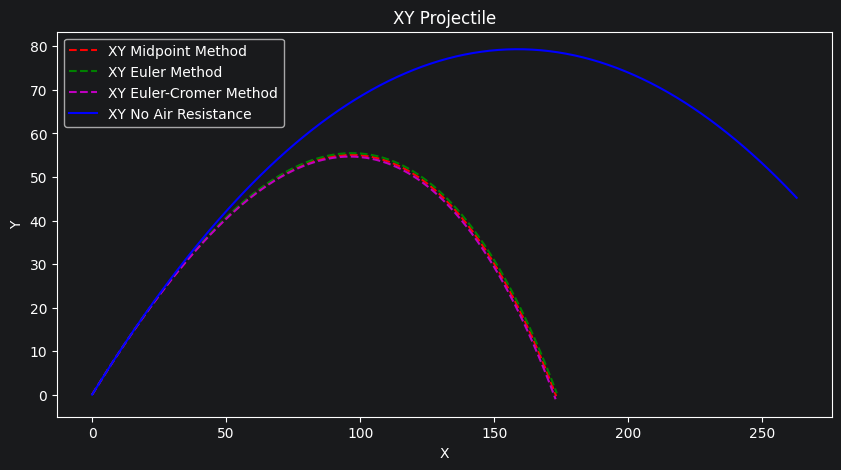

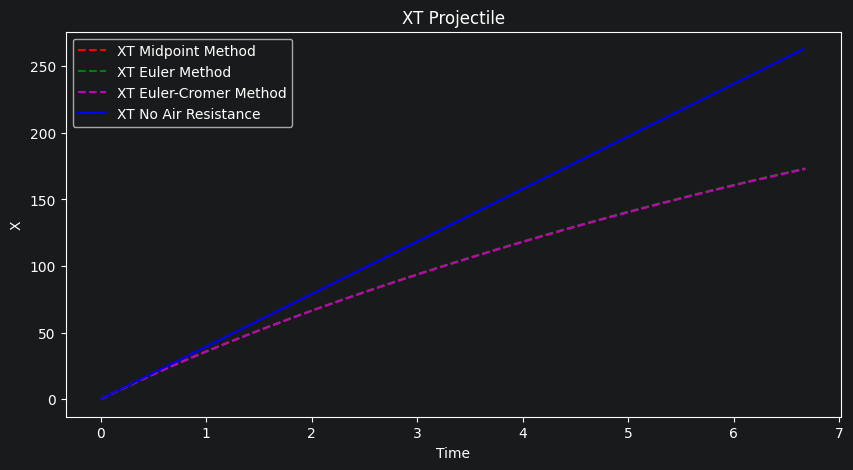

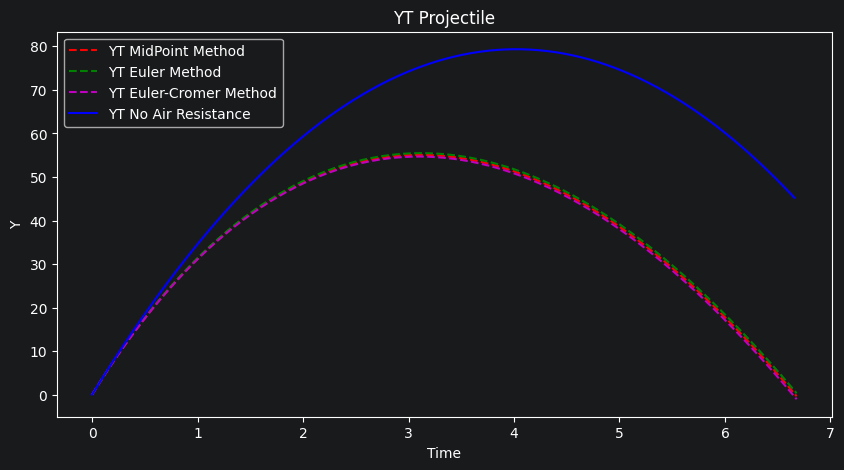

In [14]:
import matplotlib.pyplot as plt
import numpy as np

xcanvas = 1000
ycanvas = 500

# Create figures and axes for the XY projectile plot, XT projectile plot, and YT projectile plot
fig1, ax1 = plt.subplots(figsize=(xcanvas / 100, ycanvas / 100))
fig2, ax2 = plt.subplots(figsize=(xcanvas / 100, ycanvas / 100))
fig3, ax3 = plt.subplots(figsize=(xcanvas / 100, ycanvas / 100))

# Plot the XY projectile data
ax1.plot(xplot, yplot, 'r--', label='XY Midpoint Method')
ax1.plot(xplote, yplote, 'g--', label='XY Euler Method')
ax1.plot(xplotec, yplotec, 'm--', label='XY Euler-Cromer Method')
ax1.plot(xNoAir,yNoAir, 'b-', label='XY No Air Resistance')
ax1.set_title('XY Projectile')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.legend()

# Plot the XT projectile data
ax2.plot(time, xplot, 'r--', label='XT Midpoint Method')
ax2.plot(timee, xplote, 'g--', label='XT Euler Method')
ax2.plot(timeec, xplotec, 'm--', label='XT Euler-Cromer Method')
ax2.plot(timeNoAir, xNoAir, 'b-', label='XT No Air Resistance')
ax2.set_title('XT Projectile')
ax2.set_xlabel('Time')
ax2.set_ylabel('X')
ax2.legend()

# Plot the YT projectile data
ax3.plot(time, yplot, 'r--', label='YT MidPoint Method')
ax3.plot(timee, yplote, 'g--', label='YT Euler Method')
ax3.plot(timeec, yplotec, 'm--', label='YT Euler-Cromer Method')
ax3.plot(timeNoAir, yNoAir, 'b-', label='YT No Air Resistance')
ax3.set_title('YT Projectile')
ax3.set_xlabel('Time')
ax3.set_ylabel('Y')
ax3.legend()

# Show the plots
plt.show()


## Conclusions and further investigations

This notebook introduces two distinct approximations:

1. **Model approximation:** the drag law assumes constant $C_D$, constant air density, a fixed cross-sectional area, no wind, and no spin.
2. **Numerical approximation:** continuous evolution is replaced by finite timesteps and impact is detected only at step boundaries.

Keeping those approximations separate is a central habit in computational modeling. A more elaborate physical model is not useful if the numerical solution has not converged, and a highly accurate integrator cannot compensate for an inappropriate force law.

Useful follow-up experiments include:

- halve `tau` repeatedly and monitor the predicted range;
- set `Cd = 0` and confirm convergence toward the analytical no-drag trajectory;
- vary mass or cross-sectional area and explain the trend through $k$;
- interpolate between the last point above ground and first point below ground to improve the impact estimate; or
- implement a true second-order midpoint or Runge–Kutta method that evaluates acceleration at an estimated midpoint state.